In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [7]:
df = pd.read_csv("SEER Breast Cancer Dataset .csv")
df.head()

,Age,Race,Marital Status,Unnamed: 3,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,43,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),NaN,T2,N3,IIIC,Moderately differentiated; Grade II,Regional,40,Positive,Positive,19,11,1,Alive
1,47,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),NaN,T2,N2,IIIA,Moderately differentiated; Grade II,Regional,45,Positive,Positive,25,9,2,Alive
2,67,White,Married (including common law),NaN,T2,N1,IIB,Poorly differentiated; Grade III,Regional,25,Positive,Positive,4,1,2,Dead
3,46,White,Divorced,NaN,T1,N1,IIA,Moderately differentiated; Grade II,Regional,19,Positive,Positive,26,1,2,Dead
4,63,White,Married (including common law),NaN,T2,N2,IIIA,Moderately differentiated; Grade II,Regional,35,Positive,Positive,21,5,3,Dead


In [8]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Age', 'Race', 'Marital Status', 'Unnamed: 3', 'T Stage', 'N Stage',
       '6th Stage', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Status'],
      dtype='str')


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4024 non-null   int64  
 1   Race                    4024 non-null   str    
 2   Marital Status          4024 non-null   str    
 3   Unnamed: 3              0 non-null      float64
 4   T Stage                 4024 non-null   str    
 5   N Stage                 4024 non-null   str    
 6   6th Stage               4024 non-null   str    
 7   Grade                   4024 non-null   str    
 8   A Stage                 4024 non-null   str    
 9   Tumor Size              4024 non-null   int64  
 10  Estrogen Status         4024 non-null   str    
 11  Progesterone Status     4024 non-null   str    
 12  Regional Node Examined  4024 non-null   int64  
 13  Reginol Node Positive   4024 non-null   int64  
 14  Survival Months         4024 non-null   int64  
 15

In [10]:
df.describe() #statistical summary of numerical col

,Age,Unnamed: 3,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,0.0,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,NaN,30.473658,14.357107,4.158052,71.297962
std,8.963134,NaN,21.119696,8.099675,5.109331,22.921430
min,30.000000,NaN,1.000000,1.000000,1.000000,1.000000
25%,47.000000,NaN,16.000000,9.000000,1.000000,56.000000
50%,54.000000,NaN,25.000000,14.000000,2.000000,73.000000
75%,61.000000,NaN,38.000000,19.000000,5.000000,90.000000
max,69.000000,NaN,140.000000,61.000000,46.000000,107.000000


In [11]:
df.isnull().sum()

Age                          0
Race                         0
Marital Status               0
Unnamed: 3                4024
T Stage                      0
N Stage                      0
6th Stage                    0
Grade                        0
A Stage                      0
Tumor Size                   0
Estrogen Status              0
Progesterone Status          0
Regional Node Examined       0
Reginol Node Positive        0
Survival Months              0
Status                       0
dtype: int64

In [12]:
df.drop(columns=["Unnamed: 3"], inplace=True)

In [13]:
df.isnull().sum()

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

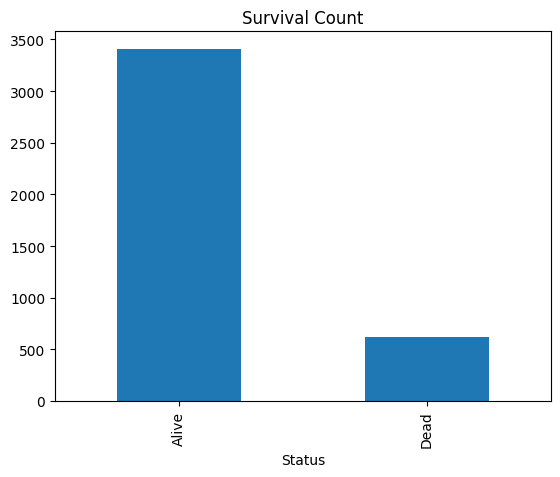

In [14]:
df["Status"].value_counts().plot(kind='bar')
plt.title("Survival Count")
plt.show()

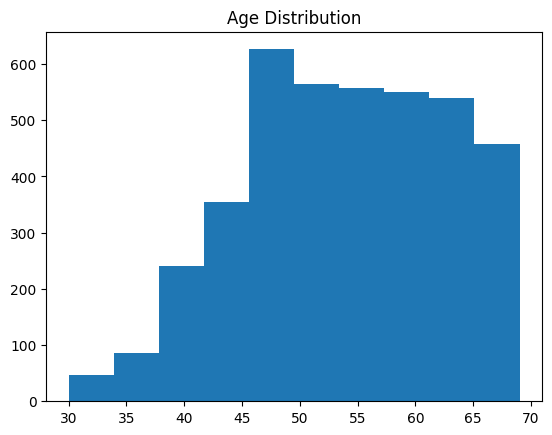

In [15]:
plt.hist(df["Age"])
plt.title("Age Distribution")
plt.show()

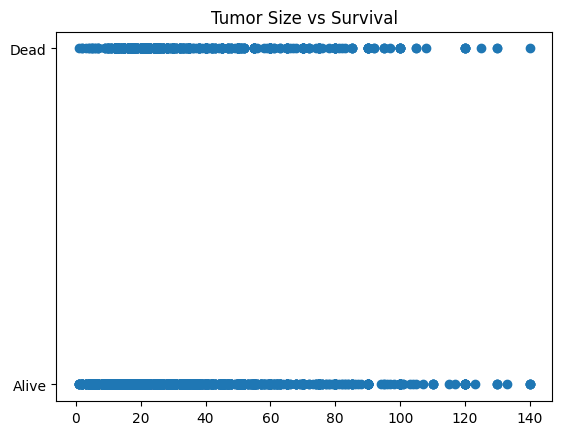

In [16]:
plt.scatter(df["Tumor Size"], df["Status"])
plt.title("Tumor Size vs Survival")
plt.show()

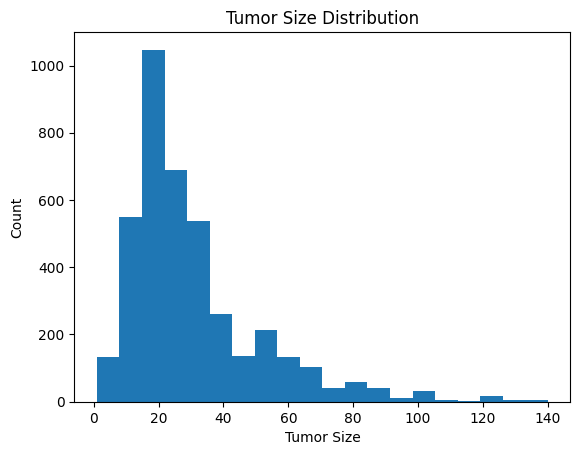

In [17]:
plt.hist(df["Tumor Size"], bins=20)
plt.title("Tumor Size Distribution")
plt.xlabel("Tumor Size")
plt.ylabel("Count")
plt.show()

In [18]:
print(df.columns)

Index(['Age', 'Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage',
       'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Status'],
      dtype='str')


In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Status"] = le.fit_transform(df["Status"])

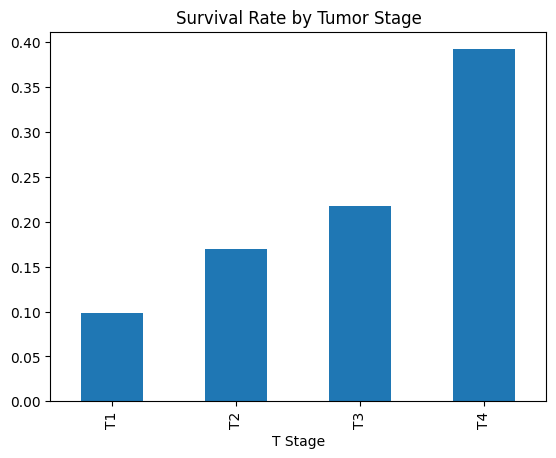

In [20]:
df.groupby("T Stage")["Status"].mean().plot(kind='bar')
plt.title("Survival Rate by Tumor Stage")
plt.show()

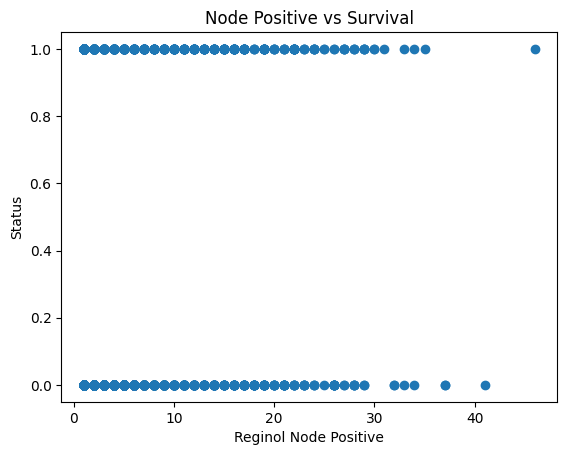

In [21]:
plt.scatter(df["Reginol Node Positive"], df["Status"])
plt.title("Node Positive vs Survival")
plt.xlabel("Reginol Node Positive")
plt.ylabel("Status")
plt.show()

In [22]:
print(df.columns.tolist())

['Age', 'Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status', 'Progesterone Status', 'Regional Node Examined', 'Reginol Node Positive', 'Survival Months', 'Status']


In [23]:
df.columns = df.columns.str.strip()

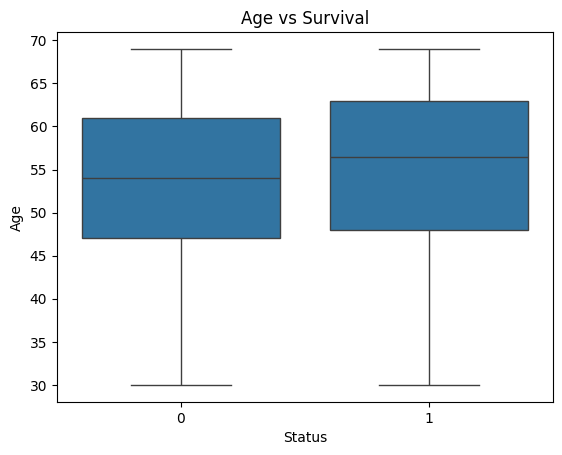

In [24]:
import seaborn as sns

sns.boxplot(x=df["Status"], y=df["Age"])
plt.title("Age vs Survival")
plt.show()

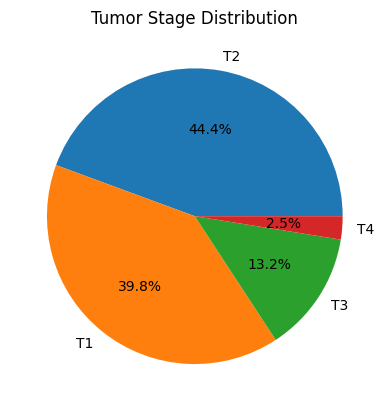

In [25]:
df["T Stage"].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Tumor Stage Distribution")
plt.show()

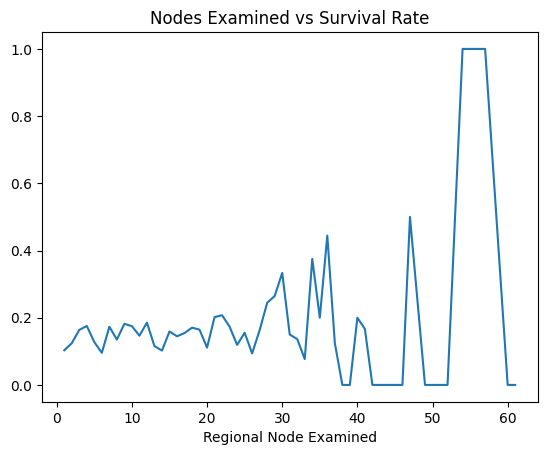

In [26]:
df.groupby("Regional Node Examined")["Status"].mean().plot()
plt.title("Nodes Examined vs Survival Rate")
plt.show()

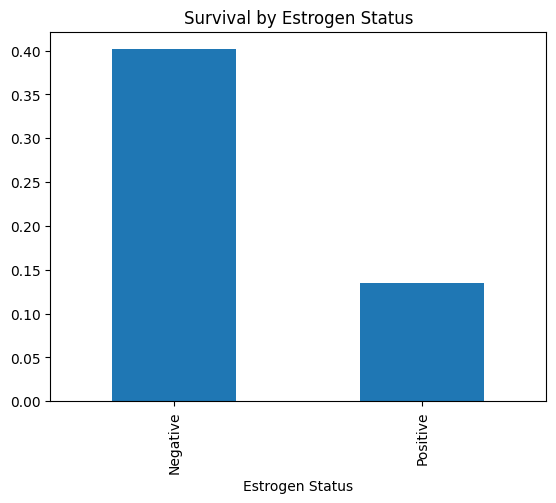

In [27]:
df.groupby("Estrogen Status")["Status"].mean().plot(kind='bar')
plt.title("Survival by Estrogen Status")
plt.show()

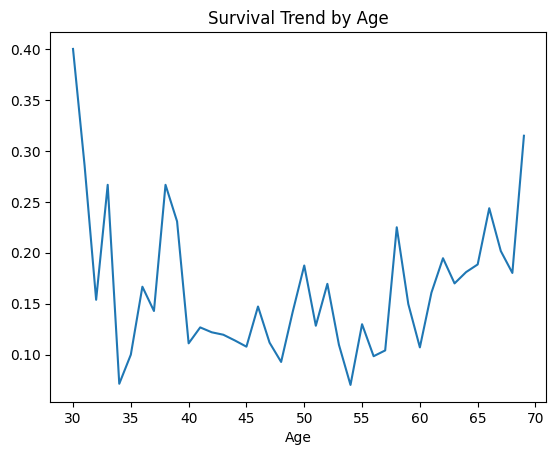

In [28]:
df.groupby("Age")["Status"].mean().plot()
plt.title("Survival Trend by Age")
plt.show()

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Status"] = le.fit_transform(df["Status"])

In [30]:
X = df.drop("Status", axis=1)
y = df["Status"]

In [31]:
for col in X.select_dtypes(include=['object', 'string', 'category']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [32]:
if 'Age Group' in X.columns:
    X['Age Group'] = X['Age Group'].astype('category').cat.codes

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [34]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [37]:
# Step 1: Import
from sklearn.ensemble import RandomForestClassifier

# Step 2: Create model
rf = RandomForestClassifier(random_state=42)

# Step 3: Train
rf.fit(X_train, y_train)

# Step 4: Predict
y_pred_rf = rf.predict(X_test)

In [38]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [39]:
from sklearn.metrics import accuracy_score

acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Decision Tree:", acc_dt)
print("Random Forest:", acc_rf)

Decision Tree: 0.8298136645962733
Random Forest: 0.901863354037267


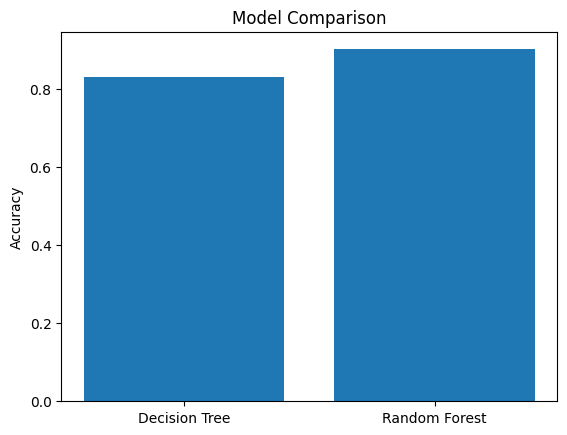

In [40]:
import matplotlib.pyplot as plt

models = [ "Decision Tree", "Random Forest"]
scores = [acc_dt, acc_rf]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

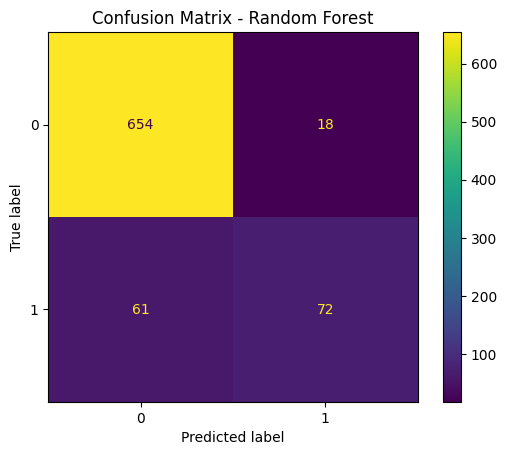

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [42]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Confusion Matrix:
 [[654  18]
 [ 61  72]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.97      0.94       672
           1       0.80      0.54      0.65       133

    accuracy                           0.90       805
   macro avg       0.86      0.76      0.79       805
weighted avg       0.90      0.90      0.89       805



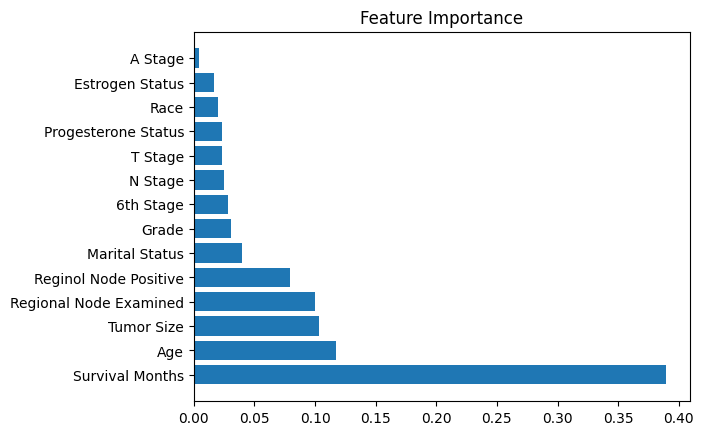

In [43]:
feature_importance = rf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.title("Feature Importance")
plt.show()

In [44]:
print(X.columns)

Index(['Age', 'Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage',
       'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months'],
      dtype='str')


In [46]:
new_patient = pd.DataFrame([[ 
    28,1,32,21,1,2,34,1,40,1,1,15,3,36
]], columns=X.columns)

prediction = rf.predict(new_patient)[0]

if prediction == 1:
    print("❌ Patient likely NOT to survive")
else:
    print("✅ Patient likely to survive")

prob = rf.predict_proba(new_patient)[0]
print("Survival Probability:", prob[0])
print("Death Probability:", prob[1])

✅ Patient likely to survive
Survival Probability: 0.55
Death Probability: 0.45


In [47]:
new_patient = new_patient[X.columns]
prediction = rf.predict(new_patient)
print(prediction)

[0]


In [48]:
print(rf.classes_)

[0 1]
